In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
os.chdir('..')

In [3]:
STOCK = 'BTC'
TF = '1h'
LEVEL = 2
PRICE = 'close'
SEQ_LENGTH = 48
SEQ_LENGTH_MACD = 28
BATCH_SIZE = 8
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.1
TEST_SPLIT = 1 - (TRAIN_SPLIT+VAL_SPLIT)
DATA_TYPE = 'float32'
FILE_NAME = f'cnn/{STOCK}_{TF}/figs'

In [4]:
from utils.utils import CreateTimeFrames

In [5]:
df = pd.read_csv(f'data/{STOCK}USD_2023_2024.csv',
                  index_col = 'Gmt time')
df.index = pd.to_datetime(df.index, format='%d.%m.%Y %H:%M:%S.%f', errors='coerce')
df = df.rename(columns={'Date':'time', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Close':'close', 'Volume':'volume'})


timeframes = [TF]
# timeframes = ['1min','5min','15min', '30min','1h', '4h','1d','1w','1m']
df = CreateTimeFrames(df,timeframes)
df_tf = df[TF]
df_tf = df_tf.iloc[-4050:,:]

# Backtester

In [6]:
os.getcwd()
from utils.backtester import MACDBacktester

# Market strategy pattern

In [7]:
df_all = pd.read_csv(f'strategy/files/df_all_{STOCK}_{TF}.csv')

In [8]:
df_all

,open,high,low,close,volume,smoothed_data,macd_line,signal_line,histo
0,69976,70042,69806,69955,23789.0,69995.771144,32.225211,11.135664,21.089547
1,69955,70199,69900,70151,29221.0,69944.541090,24.766716,17.951664,6.815052
2,70151,70236,69725,69725,37796.0,69902.972071,11.152982,14.552884,-3.399902
3,69721,70059,69480,69611,44642.0,69830.813497,-44.037806,-29.742728,-14.295078
4,69611,69860,69400,69543,43107.0,69816.069025,-35.351186,-16.451557,-18.899629
...,...,...,...,...,...,...,...,...,...
4018,70201,70239,68722,68955,22458.0,69667.303403,237.725824,446.013647,-208.287823
4019,68961,69617,68799,69405,27575.0,69356.932622,-175.208800,-45.451278,-129.757522
4020,69407,69570,69051,69129,21677.0,69164.158034,-203.521273,-119.558906,-83.962367
4021,69126,69556,68853,69548,16816.0,69216.431987,-181.537176,-46.943184,-134.593993


In [10]:
# backtester = MACDBacktester(df_test, best_params.get('Fast EMA'), best_params.get('Slow EMA'), best_params.get('Signal Line'),signal_price=signal_price, real_price=real_price)
# backtester = MACDBacktester(df_test, best_params.get('Fast EMA'), best_params.get('Slow EMA'), best_params.get('Signal Line'),signal_price=signal_price, real_price=real_price)
# backtester = MACDBacktester(df_test, best_params.get('Fast EMA'), best_params.get('Slow EMA'), best_params.get('Signal Line'),signal_price=signal_price, real_price=real_price)
backtester = MACDBacktester(df_all, signal_price='close', real_price='close',initial_capital=df_all['close'][0])
backtester.generate_signals()
backtester.backtest_strategy()
metrics, results = backtester.get_performance_metrics()
print(metrics)
backtester.print_trades()

c:\Users\arvin\Documents\Coding Project\V4\Algotrading_RL\src\utils\backtester.py:110: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '69874.55178388099' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.data.at[idx, 'total'] = float(total)
c:\Users\arvin\Documents\Coding Project\V4\Algotrading_RL\src\utils\backtester.py:108: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '69551.13564975146' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.data.at[idx, 'cash'] = float(cash)


{'Total Return (%)': 255.66330406887846, 'Annualized Return (%)': 12.477506939626437, 'Annualized Volatility (%)': 7.038927062260858, 'Sharpe Ratio': 8.068913156504443, 'Sortino Ratio': 15.407168724472696, 'Max Drawdown (%)': 5.9999176339784235, 'Win Rate (%)': 50.89058524173028}
Trade 1: Return = -0.58%
Trade 2: Return = 0.30%
Trade 3: Return = 0.04%
Trade 4: Return = -0.56%
Trade 5: Return = -0.13%
Trade 6: Return = 2.46%
Trade 7: Return = 0.38%
Trade 8: Return = -0.35%
Trade 9: Return = 0.22%
Trade 10: Return = 0.58%
Trade 11: Return = 2.38%
Trade 12: Return = 0.56%
Trade 13: Return = 0.30%
Trade 14: Return = 1.09%
Trade 15: Return = -0.14%
Trade 16: Return = -0.76%
Trade 17: Return = 0.61%
Trade 18: Return = 1.87%
Trade 19: Return = 0.04%
Trade 20: Return = -0.33%
Trade 21: Return = -0.56%
Trade 22: Return = 0.08%
Trade 23: Return = -0.36%
Trade 24: Return = -0.35%
Trade 25: Return = -0.03%
Trade 26: Return = -0.13%
Trade 27: Return = -0.32%
Trade 28: Return = 0.68%
Trade 29: Retur

In [13]:
results

,cash,holdings,total
3218,69955.000000,0.000000,69955.000000
3219,0.000000,69874.551946,69874.551946
3220,0.000000,69772.805238,69772.805238
3221,0.000000,69533.469231,69533.469231
3222,0.000000,70069.951874,70069.951874
...,...,...,...
4018,85122.310872,0.000000,85122.310872
4019,85122.310872,0.000000,85122.310872
4020,85122.310872,0.000000,85122.310872
4021,85122.310872,0.000000,85122.310872


In [11]:
tot = results['total'].diff()
tot_cum = tot.cumsum()

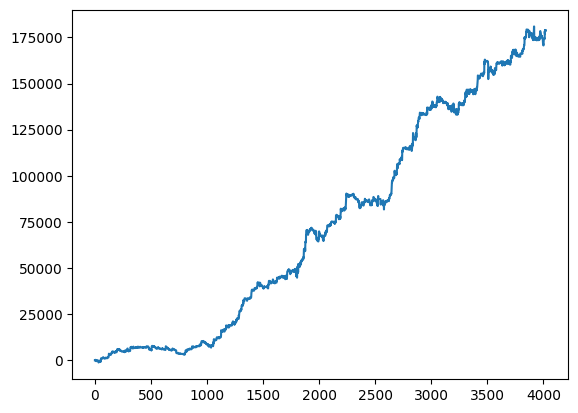

In [12]:
plt.plot(tot_cum)

# Market Strategy

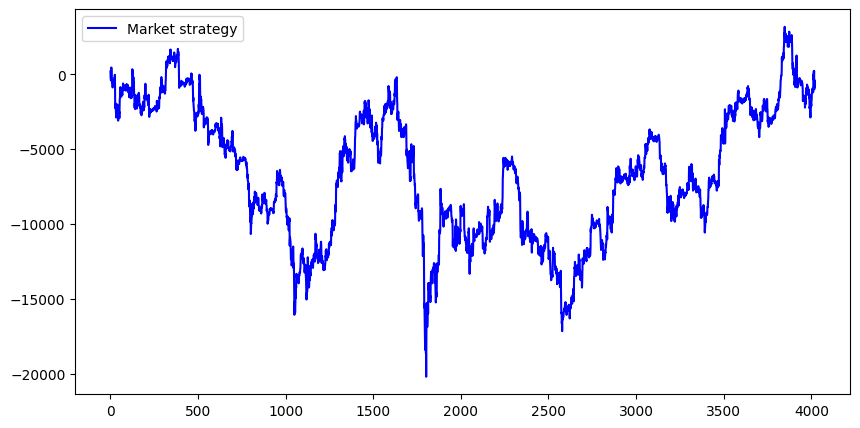

In [13]:
trade_df = pd.DataFrame({'close':df_all['close'], 'open':df_all['open']})
trade_df = trade_df.astype({
    'close': np.int32,
    'open': np.int32
})

trade_df = trade_df

trade_df['tomorrows_returns'] = 0
trade_df['tomorrows_returns'] = trade_df['close'] - trade_df['close'].shift(1)
trade_df['tomorrows_returns'] = trade_df['tomorrows_returns'].shift(-1)
# trade_df.head()

trade_df.loc[:, 'cumulative_market_return'] = np.cumsum(trade_df['tomorrows_returns'])

fig, ax =plt.subplots(1,1, figsize=(10,5))
ax.plot(trade_df['cumulative_market_return'], color='blue', label='Market strategy')
ax.legend()
plt.show()

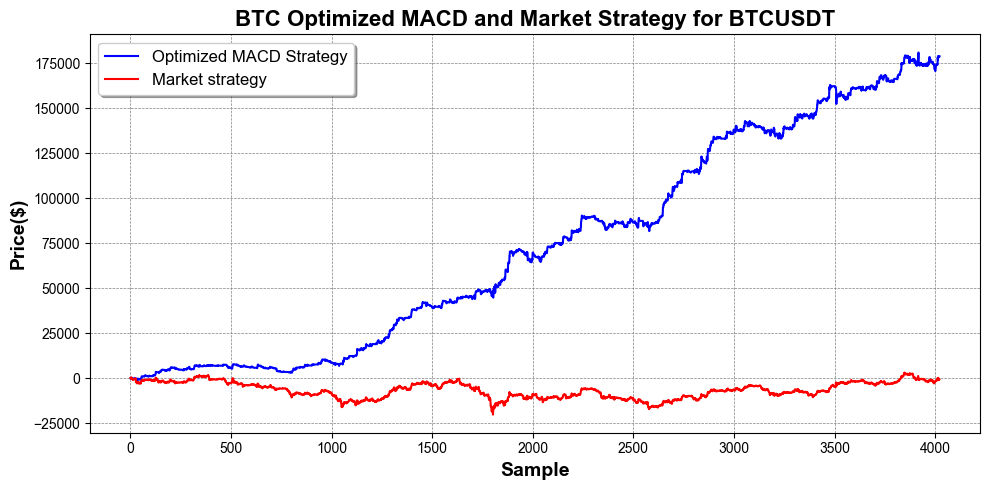

In [14]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

fig, axes = plt.subplots(1,1, figsize=(10,5))

axes.plot(tot_cum, color='blue', label='Optimized MACD Strategy')
axes.plot(trade_df['cumulative_market_return'], color='red', label='Market strategy')

axes.set_xlabel("Sample", fontsize=14, fontweight='bold')
axes.set_ylabel("Price($)", fontsize=14, fontweight='bold')
axes.set_title(f'{STOCK} Optimized MACD and Market Strategy for {STOCK}USDT', fontsize=16, fontweight='bold')

axes.grid(color='gray', linestyle='--', linewidth=0.5)  # Customize grid appearance
axes.legend(loc='best', fontsize=12, frameon=True, shadow=True, fancybox=True)

axes.spines['right'].set_visible(True)
axes.spines['bottom'].set_visible(True)
axes.spines['left'].set_visible(True)

plt.tight_layout()
# plt.savefig(f'strategy/figs/MACD_MARKET_{STOCK}{TF}.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
os.getcwd()

'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src'

# XLSTM

In [109]:
y_train_xlstm = np.load(f'data/xLSTM/{STOCK}/train_predictions.npy')
y_val_xlstm = np.load(f'data/xLSTM/{STOCK}/val_predictions.npy')
y_test_xlstm = np.load(f'data/xLSTM/{STOCK}/test_predictions.npy')

print(f'y_train_xlstm.shape is: {y_train_xlstm.shape}')
print(f'y_val_xlstm.shape is: {y_val_xlstm.shape}')
print(f'y_test_xlstm.shape is: {y_test_xlstm.shape}')

y_xlstm = np.vstack((y_train_xlstm, y_val_xlstm, y_test_xlstm))
print(f'y_xlstm.shape is: {y_xlstm.shape}')

y_train_xlstm.shape is: (2816, 48, 1)
y_val_xlstm.shape is: (403, 48, 1)
y_test_xlstm.shape is: (805, 48, 1)
y_xlstm.shape is: (4024, 48, 1)


In [110]:
y_xlstm = y_xlstm[:,-1,:].squeeze()

In [111]:
y_xlstm.shape

(4024,)

In [112]:
y_xlstm

array([70335.65 , 70473.46 , 70403.94 , ..., 68990.016, 69426.414,
       69827.68 ], dtype=float32)

In [113]:
y_xlstm = np.roll(y_xlstm, -2)
y_xlstm

array([70403.94, 70470.57, 69861.46, ..., 69827.68, 70335.65, 70473.46],
      dtype=float32)

In [114]:
y_xlstm = y_xlstm[1:]
y_xlstm

array([70470.57, 69861.46, 69239.63, ..., 69827.68, 70335.65, 70473.46],
      dtype=float32)

In [115]:
y_xlstm.shape

(4023,)

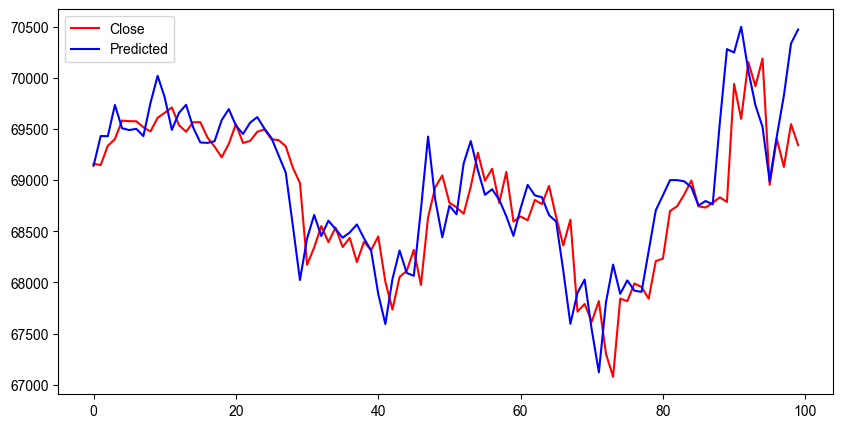

In [116]:
fig, ax = plt.subplots(1,1, figsize=(10,5))
ax.plot(trade_df['close'][-100:].to_numpy(), color='red', label='Close')
ax.plot(y_xlstm[-100:], color='blue', label='Predicted')
plt.legend()


## Modified backterster

In [117]:
import numpy as np
import pandas as pd

class Modified_MACDBacktester:
    def __init__(self, data, signal_price='smoothed_data', real_price='close',
                 sell_fee=0.115, buy_fee=0.115, initial_capital=100):
        """
        It works as a trade analyzer with a specific amount of money and trading cost.

        :param data: DataFrame containing different features.
        :param signal_price: For producing buy and sell signals (default: 'smoothed_data').
        :param real_price: For trading (default: 'close').
        :param sell_fee: Sell trading cost in percentage (default: 0.115).
        :param buy_fee: Buy trading cost in percentage (default: 0.115).
        :param initial_capital: Initial capital.
        """
        self.data = data.copy()
        self.signal_price = signal_price
        self.real_price = real_price
        self.sell_fee_percent = sell_fee / 100
        self.buy_fee_percent = buy_fee / 100
        self.initial_capital = initial_capital
        self.trades = []
        self.data['positions'] = 0

    def generate_signals(self):
        """
        Generates trading signals based on the MACD-XLSTM strategy.
        
        Buy signal (1) is generated when:
          - The 'macd_line' crosses above 'signal_line' (i.e. today's MACD > Signal and yesterday’s MACD ≤ Signal)
          - AND the XLSTM forecast is above the current close (y_xlstm > close)
        
        Sell signal (-1) is generated when:
          - The 'macd_line' crosses below 'signal_line' (i.e. today's MACD < Signal and yesterday’s MACD ≥ Signal)
          - AND the XLSTM forecast is below the current close (y_xlstm < close)
        
        After generating the raw signals, the method adjusts to ensure:
          - The first trade is not a sell.
          - If the final signal is a buy, it forces a sell at the end.
        
        Finally, it converts these raw signals into a binary positions indicator (1 for holding, 0 for not).
        """
        # Define buy and sell conditions
        buy_signals = (self.data['macd_line'] > self.data['signal_line']) & \
                      (self.data['macd_line'].shift(1) <= self.data['signal_line'].shift(1)) & \
                      (self.data['y_xlstm'] > self.data['close'])
        sell_signals = (self.data['macd_line'] < self.data['signal_line']) & \
                       (self.data['macd_line'].shift(1) >= self.data['signal_line'].shift(1)) & \
                       (self.data['y_xlstm'] < self.data['close'])
        
        # Initialize raw signals array: 1 for Buy, -1 for Sell, 0 for no action.
        raw_signals = np.zeros(len(self.data), dtype=np.int8)
        holding_position = False

        # Loop through each row to set signals based on the conditions and current holding state.
        for i in range(len(self.data)):
            if buy_signals.iloc[i] and not holding_position:
                raw_signals[i] = 1
                holding_position = True
            elif sell_signals.iloc[i] and holding_position:
                raw_signals[i] = -1
                holding_position = False

        # Adjust the signals:
        # 1. If the first nonzero signal is a sell, remove it.
        trade_idx = np.where(raw_signals != 0)[0]
        if len(trade_idx) > 0 and raw_signals[trade_idx[0]] == -1:
            raw_signals[trade_idx[0]] = 0

        # 2. If the last signal is a buy, force a sell at the end.
        if len(trade_idx) > 0 and raw_signals[trade_idx[-1]] == 1:
            raw_signals[-1] = -1

        # Save the raw signals in a dedicated column.
        self.data['signals_macd_xlstm'] = raw_signals

        # Convert raw signals to binary positions: 1 if in position, 0 if not.
        positions = np.zeros(len(self.data), dtype=np.int8)
        current_position = 0
        for i, signal in enumerate(raw_signals):
            if signal == 1:
                current_position = 1
            elif signal == -1:
                current_position = 0
            positions[i] = current_position
        self.data['positions'] = positions

        return self.data

    def backtest_strategy(self):
        """
        Backtests the strategy and calculates performance metrics.
        (Implementation remains unchanged.)
        """
        self.data['price'] = self.data[self.real_price]
        self.data['positions'] = self.data['positions'].astype(int)
        self.data['positions_diff'] = self.data['positions'].diff()
        self.data['positions_diff'].fillna(0)

        # Initialize cash and holdings
        self.data['cash'] = self.initial_capital
        self.data['holdings'] = 0.0
        self.data['total'] = self.initial_capital

        cash = self.initial_capital
        holdings = 0.0
        position = 0  # number of shares held
        buy_price = 0.0
        win_count = 0  
        total_trades = 0

        for idx, row in self.data.iterrows():
            position_change = row['positions_diff']
            price = row['price']
            if position_change == 1:  # Enter long position
                shares_to_buy = round(cash / price, 8)
                shares_to_buy *= (1 - self.buy_fee_percent)

                if shares_to_buy > 0.00002:
                    buy_price = round(cash / shares_to_buy, 8)
                    total_cost = round(shares_to_buy * buy_price, 8)
                    cash -= total_cost
                    holdings += shares_to_buy * price
                    position += shares_to_buy

            elif position_change == -1 and position > 0:  # Exit long position
                sell_price = price * (1 - self.sell_fee_percent)
                total_proceeds = position * sell_price
                cash += total_proceeds
                holdings -= position * sell_price
                trade_return = (sell_price - buy_price) / buy_price * 100
                self.trades.append(trade_return)
                position = 0
                total_trades += 1
                if trade_return > 0:
                    win_count += 1
            else:
                holdings = position * price

            total = cash + holdings
            self.data.at[idx, 'cash'] = float(cash)
            self.data.at[idx, 'holdings'] = holdings
            self.data.at[idx, 'total'] = float(total)

        if position > 0:
            price = self.data.iloc[-1]['price']
            sell_price = price * (1 - self.sell_fee_percent)
            total_proceeds = position * sell_price
            cash += total_proceeds
            trade_return = (sell_price - buy_price) / buy_price * 100
            self.trades.append(trade_return)
            position = 0
            total_trades += 1
            if trade_return > 0:
                win_count += 1
            total = cash + holdings
            self.data.at[self.data.index[-1], 'cash'] = cash
            self.data.at[self.data.index[-1], 'holdings'] = holdings
            self.data.at[self.data.index[-1], 'total'] = total

        self.results = self.data[['cash', 'holdings', 'total']]
        self.win_rate = (win_count / total_trades * 100) if total_trades > 0 else 0
        return self.data

    def get_performance_metrics(self):
        """
        Calculates and returns performance metrics.
        (Implementation remains unchanged.)
        """
        if not hasattr(self, 'results'):
            print("Please run backtest_strategy() before calculating performance metrics.")
            return None

        total_return = (self.results['total'].iloc[-1] - self.initial_capital) / self.initial_capital * 100
        returns = self.results['total'].pct_change().fillna(0)
        annualized_return = ((1 + returns.mean()) ** 365 - 1) * 100  # Assuming daily returns
        annualized_volatility = returns.std() * np.sqrt(365) * 100

        periods_per_year = 8760
        annual_rf_rate = 0.04  
        daily_rf_rate = annual_rf_rate / 365  
        hourly_rf_rate = daily_rf_rate / 24  

        excess_returns = returns - hourly_rf_rate
        mean_hourly_excess = excess_returns.mean()
        std_hourly = returns.std()  
        sharpe_ratio = (mean_hourly_excess / std_hourly) * np.sqrt(periods_per_year) if std_hourly != 0 else np.nan

        target_return = hourly_rf_rate  
        downside_returns = returns.copy()
        downside_returns[downside_returns > target_return] = 0
        std_downside = downside_returns.std()
        annualized_downside_deviation = std_downside * np.sqrt(periods_per_year)
        annualized_excess_return = mean_hourly_excess * periods_per_year
        sortino_ratio = annualized_excess_return / annualized_downside_deviation if annualized_downside_deviation != 0 else np.nan

        max_drawdown = ((self.results['total'].cummax() - self.results['total']) / self.results['total'].cummax()).max() * 100

        metrics = {
            'Total Return (%)': total_return,
            'Annualized Return (%)': annualized_return,
            'Annualized Volatility (%)': annualized_volatility,
            'Sharpe Ratio': sharpe_ratio,
            'Sortino Ratio': sortino_ratio,
            'Max Drawdown (%)': max_drawdown,
            'Win Rate (%)': self.win_rate
        }
        return metrics, self.results

    def print_trades(self):
        """
        Prints individual trade returns.
        """
        if not self.trades:
            print("No trades have been executed.")
            return
        for idx, trade_return in enumerate(self.trades, 1):
            print(f"Trade {idx}: Return = {trade_return:.2f}%")
        total_return = sum(self.trades)
        print(f"Total Return from trades: {total_return:.2f}%")


In [118]:
df_all.columns

Index(['open', 'high', 'low', 'close', 'volume', 'smoothed_data', 'macd_line',
       'signal_line', 'histo', 'y_xlstm'],
      dtype='object')

In [119]:
df_all.shape

(4023, 10)

In [120]:
df_all.loc[:,'y_xlstm'] = y_xlstm

In [121]:
backtester = Modified_MACDBacktester(df_all, signal_price='close', real_price='close',initial_capital=df_all['close'][0])
backtester.generate_signals()
backtester.backtest_strategy()
metrics, results = backtester.get_performance_metrics()
print(metrics)
backtester.print_trades()

C:\Users\arvin\AppData\Local\Temp\ipykernel_8888\2289309262.py:144: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '69874.55178388099' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.data.at[idx, 'total'] = float(total)
C:\Users\arvin\AppData\Local\Temp\ipykernel_8888\2289309262.py:142: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '69551.13564975146' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.data.at[idx, 'cash'] = float(cash)


{'Total Return (%)': 322.78369299305984, 'Annualized Return (%)': 14.313602288551586, 'Annualized Volatility (%)': 7.727908096756994, 'Sharpe Ratio': 8.376367769911894, 'Sortino Ratio': 15.11281579984993, 'Max Drawdown (%)': 6.014181252289273, 'Win Rate (%)': 67.14285714285714}
Trade 1: Return = -0.58%
Trade 2: Return = 0.30%
Trade 3: Return = -2.57%
Trade 4: Return = 2.67%
Trade 5: Return = 2.38%
Trade 6: Return = 1.09%
Trade 7: Return = -1.48%
Trade 8: Return = 1.87%
Trade 9: Return = -0.10%
Trade 10: Return = -0.56%
Trade 11: Return = 0.08%
Trade 12: Return = -0.14%
Trade 13: Return = -0.19%
Trade 14: Return = 0.29%
Trade 15: Return = 1.60%
Trade 16: Return = 3.25%
Trade 17: Return = -3.04%
Trade 18: Return = 0.05%
Trade 19: Return = 1.01%
Trade 20: Return = -0.24%
Trade 21: Return = 0.78%
Trade 22: Return = 0.59%
Trade 23: Return = -0.11%
Trade 24: Return = -0.22%
Trade 25: Return = 0.52%
Trade 26: Return = -0.25%
Trade 27: Return = -0.82%
Trade 28: Return = 0.40%
Trade 29: Return 

In [122]:
tot_xlstm = results['total'].diff()
tot_cum_xlstm = tot_xlstm.cumsum()

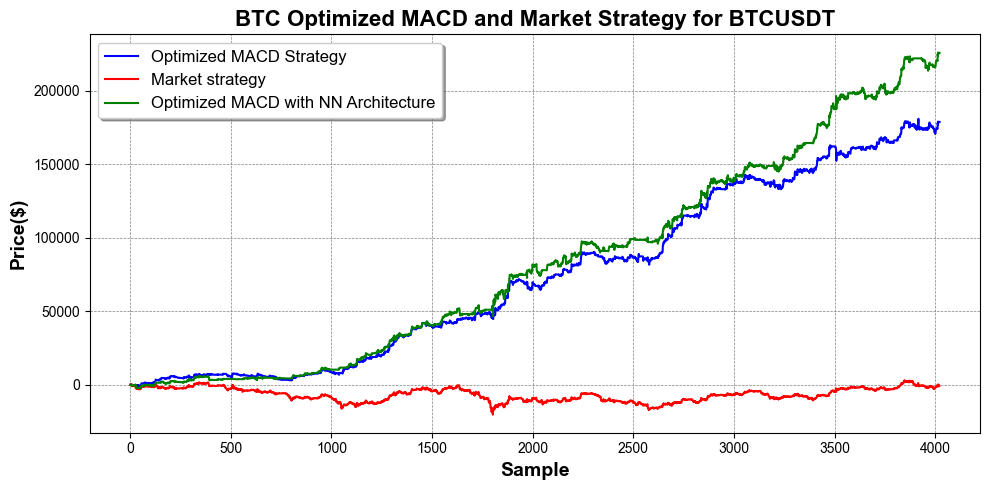

In [123]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

fig, axes = plt.subplots(1,1, figsize=(10,5))

axes.plot(tot_cum, color='blue', label='Optimized MACD Strategy')
axes.plot(trade_df['cumulative_market_return'], color='red', label='Market strategy')
axes.plot(tot_cum_xlstm, color = 'green', label = 'Optimized MACD with NN Architecture')

axes.set_xlabel("Sample", fontsize=14, fontweight='bold')
axes.set_ylabel("Price($)", fontsize=14, fontweight='bold')
axes.set_title(f'{STOCK} Optimized MACD and Market Strategy for {STOCK}USDT', fontsize=16, fontweight='bold')

axes.grid(color='gray', linestyle='--', linewidth=0.5)  # Customize grid appearance
axes.legend(loc='best', fontsize=12, frameon=True, shadow=True, fancybox=True)

axes.spines['right'].set_visible(True)
axes.spines['bottom'].set_visible(True)
axes.spines['left'].set_visible(True)

plt.tight_layout()
# plt.savefig(f'strategy/figs/MACD_MARKET_{STOCK}{TF}.png', dpi=300, bbox_inches='tight')
plt.show()